# IoT Traffic Analysis v8 — Packet + Summary (Two-Branch) (UNSW/Dryad)

This notebook implements **v8 packet features + v8 summary features** using a **two-branch** model:

- **Packet branch**: 1D CNN over a window of packet-level features (T × Fp)
- **Summary branch**: MLP over window-level summary features (Fs)
- **Fusion**: concatenate embeddings → classifier

Evaluation:
- Window-level metrics
- Device-level metrics via mean-probability aggregation over windows


In [6]:
# If running in a fresh environment, install deps as needed:
# !pip install scapy tensorflow scikit-learn pandas numpy matplotlib

import os
import math
import random
import numpy as np
import pandas as pd

from scapy.all import PcapReader
from scapy.layers.inet import IP, TCP, UDP, ICMP

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


## 1) Dataset location
Set `PCAP_DIR` to the folder where you extracted `pcaps.zip` from the Dryad dataset.


In [7]:
# === UPDATE THIS PATH ===
PCAP_DIR = "unsw-dataset/pcaps"   # e.g. "/content/pcaps" or "./pcaps"

assert os.path.isdir(PCAP_DIR), f"PCAP_DIR not found: {PCAP_DIR}"
pcap_files = sorted([os.path.join(PCAP_DIR, f) for f in os.listdir(PCAP_DIR) if f.endswith('.pcap')])

print("PCAP count:", len(pcap_files))
print("Example:", pcap_files[:3])


PCAP count: 26
Example: ['unsw-dataset/pcaps/AmazonEcho_44650d56ccd3.pcap', 'unsw-dataset/pcaps/AugustDoorBell_e076d03f00ae.pcap', 'unsw-dataset/pcaps/AwairAirQuality_70886b100fc6.pcap']


## 2) v8 device-type taxonomy + mapping
Same mapping as other v8 notebooks. Exclude `hub_gateway_bridge` by default.


In [8]:
from collections import Counter

device_to_type_v7 = {
    "SamsungCamera_00166cab6b88": "camera_streamer",
    "BelkinCamera_b4750eece5a9": "camera_streamer",
    "NestDropCam_308cfb2fe4b2": "camera_streamer",
    "TPLinkCamera_f4f26D9351f1": "camera_streamer",
    "CanaryCamera_7c70bc5d5edc": "camera_streamer",
    "NetatmoWelcome_70ee50183443": "camera_streamer",
    "WithingsBabyMonitor_0024e41118a8": "camera_streamer",
    "RingDoorBell_884aea31669d": "camera_streamer",
    "AugustDoorBell_e076d03f00ae": "camera_streamer",

    "AwairAirQuality_70886b100fc6": "sensor_meter",
    "NetatmoWeatherStation_70ee5003b8ac": "sensor_meter",
    "WithingsSleepSensor_0024e42028c6": "sensor_meter",
    "WithingsSmartScale_0024e41b6f96": "sensor_meter",
    "BlipCareBPMeter_746a89002e25": "sensor_meter",
    "NestProtect_18b43025bee4": "sensor_meter",
    "BelkinWemoMotionSensor_ec1a59832811": "sensor_meter",

    "PhilipsHue_0017882b9a25": "actuator_light_plug",
    "LiFXBulb_d073d5018308": "actuator_light_plug",
    "TPLinkSmartPlug_50c7bf005639": "actuator_light_plug",
    "BelkinWemoSwitch_ec1a5979f489": "actuator_light_plug",

    "SamsungSmartThings_d052a800675e": "hub_gateway_bridge",
    "HPPrinter_705a0fe49bc0": "hub_gateway_bridge",

    "TribySpeaker_18B79E022044": "media_speaker_display",
    "PixStarPhotoFrame_e076d033bb85": "media_speaker_display",
    "HelloBarbie_28c2ddffa52d": "media_speaker_display",
    "iHome_74c63b29d71d": "media_speaker_display",
    "AmazonEcho_44650d56ccd3": "media_speaker_display",
}

v7_to_v8 = {
    "camera_streamer": "continuous_streaming",
    "sensor_meter": "low_rate_telemetry",
    "actuator_light_plug": "interactive_actuators",
    "media_speaker_display": "smart_media_clients",
    "hub_gateway_bridge": None,  # excluded
}

device_to_type_v8 = {dev: v7_to_v8.get(t, None) for dev, t in device_to_type_v7.items()}

DROP_NONE_TYPES = True

target_types = sorted([t for t in set(device_to_type_v8.values()) if t is not None])
print("v8 target types:", target_types)
print("Counts:", Counter([t for t in device_to_type_v8.values() if t is not None]))


v8 target types: ['continuous_streaming', 'interactive_actuators', 'low_rate_telemetry', 'smart_media_clients']
Counts: Counter({'continuous_streaming': 9, 'low_rate_telemetry': 7, 'smart_media_clients': 5, 'interactive_actuators': 4})


## 3) Build device table from PCAPs


In [9]:
def device_id_from_path(pcap_path: str) -> str:
    return os.path.basename(pcap_path).replace(".pcap", "")

rows = []
for p in pcap_files:
    dev = device_id_from_path(p)
    v8_type = device_to_type_v8.get(dev, None)
    if DROP_NONE_TYPES and v8_type is None:
        continue
    if v8_type is None:
        v8_type = "unknown_infrastructure"
    rows.append({"device_id": dev, "device_type": v8_type, "pcap_path": p})

df_dev = pd.DataFrame(rows).sort_values(["device_type", "device_id"]).reset_index(drop=True)
print("Devices included:", len(df_dev))
display(df_dev.head(10))
print(df_dev["device_type"].value_counts())


Devices included: 23


,device_id,device_type,pcap_path
0,AugustDoorBell_e076d03f00ae,continuous_streaming,unsw-dataset/pcaps/AugustDoorBell_e076d03f00ae...
1,BelkinCamera_b4750eece5a9,continuous_streaming,unsw-dataset/pcaps/BelkinCamera_b4750eece5a9.pcap
2,CanaryCamera_7c70bc5d5edc,continuous_streaming,unsw-dataset/pcaps/CanaryCamera_7c70bc5d5edc.pcap
3,NestDropCam_308cfb2fe4b2,continuous_streaming,unsw-dataset/pcaps/NestDropCam_308cfb2fe4b2.pcap
4,NetatmoWelcome_70ee50183443,continuous_streaming,unsw-dataset/pcaps/NetatmoWelcome_70ee50183443...
5,RingDoorBell_884aea31669d,continuous_streaming,unsw-dataset/pcaps/RingDoorBell_884aea31669d.pcap
6,SamsungCamera_00166cab6b88,continuous_streaming,unsw-dataset/pcaps/SamsungCamera_00166cab6b88....
7,TPLinkCamera_f4f26D9351f1,continuous_streaming,unsw-dataset/pcaps/TPLinkCamera_f4f26D9351f1.pcap
8,BelkinWemoSwitch_ec1a5979f489,interactive_actuators,unsw-dataset/pcaps/BelkinWemoSwitch_ec1a5979f4...
9,LiFXBulb_d073d5018308,interactive_actuators,unsw-dataset/pcaps/LiFXBulb_d073d5018308.pcap


device_type
continuous_streaming     8
low_rate_telemetry       6
smart_media_clients      5
interactive_actuators    4
Name: count, dtype: int64


## 4) Train/test split by device (stratified)


In [10]:
types = sorted(df_dev["device_type"].unique())
type_to_idx = {t: i for i, t in enumerate(types)}
idx_to_type = {i: t for t, i in type_to_idx.items()}
df_dev["y"] = df_dev["device_type"].map(type_to_idx).astype(int)

train_df, test_df = train_test_split(
    df_dev,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df_dev["device_type"]
)

print("Train devices:", len(train_df), "Test devices:", len(test_df))
print("Train distribution:\n", train_df["device_type"].value_counts())
print("Test distribution:\n", test_df["device_type"].value_counts())


Train devices: 16 Test devices: 7
Train distribution:
 device_type
continuous_streaming     6
low_rate_telemetry       4
interactive_actuators    3
smart_media_clients      3
Name: count, dtype: int64
Test distribution:
 device_type
continuous_streaming     2
smart_media_clients      2
low_rate_telemetry       2
interactive_actuators    1
Name: count, dtype: int64


## 5) Feature extraction (packet + summary per window)

We compute, for each window:
- `X_pkt`: shape (T, Fp) packet-level features (Fp=17)
- `X_sum`: shape (Fs,) window summary features (Fs=22)

Windowing defaults:
- `PKTS_PER_WINDOW=60`, `STRIDE=60`


In [11]:
PKTS_PER_WINDOW = 60
STRIDE = 60
MAX_WINDOWS_PER_DEVICE = 1200

# Packet features
Fp = 17
IAT_CAP_SECONDS = 2.0
MTU_NORM = 1500.0

# Summary features
Fs = 22
BURST_GAP_SECONDS = 0.5

def safe_payload_len(pkt) -> int:
    if pkt.haslayer(TCP):
        return int(len(bytes(pkt[TCP].payload)))
    if pkt.haslayer(UDP):
        return int(len(bytes(pkt[UDP].payload)))
    return 0

def tcp_flag_bits(tcp_layer) -> np.ndarray:
    def has(flag_char):
        return 1.0 if flag_char in str(tcp_layer.flags) else 0.0
    return np.array([has("S"), has("A"), has("F"), has("R"), has("P"), has("U")], dtype=np.float32)

def infer_device_ip(pcap_path: str, scan_packets: int = 200) -> str | None:
    counts = {}
    seen = 0
    with PcapReader(pcap_path) as pcap:
        for pkt in pcap:
            if not pkt.haslayer(IP):
                continue
            src = pkt[IP].src
            counts[src] = counts.get(src, 0) + 1
            seen += 1
            if seen >= scan_packets:
                break
    return max(counts.items(), key=lambda kv: kv[1])[0] if counts else None

def is_keepalive_like(pkt) -> float:
    if not pkt.haslayer(TCP):
        return 0.0
    pl = safe_payload_len(pkt)
    if pl > 1:
        return 0.0
    fl = str(pkt[TCP].flags)
    if ("A" in fl) and ("S" not in fl) and ("F" not in fl) and ("R" not in fl) and len(pkt) <= 80:
        return 1.0
    return 0.0

def _norm_log1p(x: float, cap: float) -> float:
    x = min(max(x, 0.0), cap)
    return math.log1p(x) / math.log1p(cap)

def _log_ratio(a: float, b: float, clip: float = 1000.0) -> float:
    r = a / (b + 1.0)
    r = min(r, clip)
    return math.log1p(r) / math.log1p(clip)

def summarize_items(items):
    n = len(items)
    if n == 0:
        return None

    bytes_up = sum(it["plen"] for it in items if it["dir"] == 1.0)
    bytes_down = sum(it["plen"] for it in items if it["dir"] == 0.0)
    pkts_up = sum(1 for it in items if it["dir"] == 1.0)
    pkts_down = n - pkts_up

    iats = [it["iat"] for it in items[1:]]
    if len(iats) == 0:
        iat_mean = iat_std = iat_max = 0.0
    else:
        iat_mean = float(np.mean(iats))
        iat_std = float(np.std(iats))
        iat_max = float(np.max(iats))

    bursts = 1
    for it in items[1:]:
        if it["iat"] > BURST_GAP_SECONDS:
            bursts += 1
    burst_count_norm = bursts / n
    avg_burst_size_norm = (n / bursts) / n

    tcp = sum(1 for it in items if it["proto"] == "tcp")
    udp = sum(1 for it in items if it["proto"] == "udp")
    icmp = sum(1 for it in items if it["proto"] == "icmp")
    other = n - tcp - udp - icmp

    dns_like = sum(1 for it in items if it["dns_like"])
    tls_like = sum(1 for it in items if it["tls_like"])

    unique_dsts = len(set(it["dst"] for it in items if it["dst"] is not None))
    syn_count = sum(1 for it in items if it["syn"])
    rst_count = sum(1 for it in items if it["rst"])

    flows = set(it["flow"] for it in items if it["flow"] is not None)
    flow_count = max(1, len(flows))
    total_bytes = sum(it["plen"] for it in items)
    bytes_per_flow_norm = (total_bytes / flow_count) / MTU_NORM

    bytes_up_norm = bytes_up / (n * MTU_NORM)
    bytes_down_norm = bytes_down / (n * MTU_NORM)
    pkts_up_frac = pkts_up / n
    pkts_down_frac = pkts_down / n

    feat = np.array([
        bytes_up_norm,
        bytes_down_norm,
        pkts_up_frac,
        pkts_down_frac,
        _log_ratio(pkts_up, pkts_down),
        _log_ratio(bytes_up, bytes_down),
        _norm_log1p(iat_mean, IAT_CAP_SECONDS),
        _norm_log1p(iat_std, IAT_CAP_SECONDS),
        _norm_log1p(iat_max, IAT_CAP_SECONDS),
        burst_count_norm,
        avg_burst_size_norm,
        tcp / n,
        udp / n,
        icmp / n,
        other / n,
        dns_like / n,
        tls_like / n,
        unique_dsts / n,
        syn_count / n,
        rst_count / n,
        len(flows) / n,
        bytes_per_flow_norm,
    ], dtype=np.float32)

    assert feat.shape[0] == Fs
    return feat

def iter_windows_packet_and_summary(pcap_path: str,
                                   device_ip: str | None,
                                   label: int,
                                   max_windows: int = MAX_WINDOWS_PER_DEVICE,
                                   pkts_per_window: int = PKTS_PER_WINDOW,
                                   stride: int = STRIDE):
    """Yield (X_pkt[T,Fp], X_sum[Fs], y) per window."""
    recent_tcp_keys = []
    recent_tcp_set = set()
    RECENT_MAX = 5000

    prev_time = None
    buf = []   # list of per-packet dicts for summary + packet feats
    windows_yielded = 0

    with PcapReader(pcap_path) as pcap:
        for pkt in pcap:
            if not pkt.haslayer(IP):
                continue

            this_time = float(getattr(pkt, "time", 0.0))
            if prev_time is None or this_time <= 0.0 or prev_time <= 0.0:
                iat = 0.0
            else:
                iat = max(0.0, this_time - prev_time)
            prev_time = this_time
            iat = min(iat, IAT_CAP_SECONDS)

            ip = pkt[IP]
            src = getattr(ip, "src", None)
            dst = getattr(ip, "dst", None)
            ttl = float(getattr(ip, "ttl", 0.0))

            plen = float(len(pkt))
            payload_len = float(safe_payload_len(pkt))
            direction = 1.0 if (device_ip is not None and src == device_ip) else 0.0

            # Protocol one-hot
            proto = int(getattr(ip, "proto", 0))
            if proto == 6:
                proto_oh = np.array([1.0, 0.0, 0.0, 0.0], dtype=np.float32)
            elif proto == 17:
                proto_oh = np.array([0.0, 1.0, 0.0, 0.0], dtype=np.float32)
            elif proto == 1:
                proto_oh = np.array([0.0, 0.0, 1.0, 0.0], dtype=np.float32)
            else:
                proto_oh = np.array([0.0, 0.0, 0.0, 1.0], dtype=np.float32)

            # For summary fields
            proto_name = "other"
            dns_like = False
            tls_like = False
            syn = False
            rst = False
            flow = None

            # For packet flags
            flags = np.zeros(6, dtype=np.float32)
            is_retrans_like = 0.0

            if pkt.haslayer(TCP):
                proto_name = "tcp"
                tcp = pkt[TCP]
                flags = tcp_flag_bits(tcp)
                seq = int(getattr(tcp, "seq", 0))
                sport = int(getattr(tcp, "sport", 0))
                dport = int(getattr(tcp, "dport", 0))
                fl = str(tcp.flags)
                syn = ("S" in fl)
                rst = ("R" in fl)
                dns_like = (sport == 53 or dport == 53)
                tls_like = (sport == 443 or dport == 443)
                flow = (src, dst, sport, dport, 6)

                key = (src, dst, sport, dport, seq, int(payload_len))
                if key in recent_tcp_set:
                    is_retrans_like = 1.0
                recent_tcp_keys.append(key)
                recent_tcp_set.add(key)
                if len(recent_tcp_keys) > RECENT_MAX:
                    old = recent_tcp_keys.pop(0)
                    if old not in recent_tcp_keys:
                        recent_tcp_set.discard(old)

            elif pkt.haslayer(UDP):
                proto_name = "udp"
                udp = pkt[UDP]
                sport = int(getattr(udp, "sport", 0))
                dport = int(getattr(udp, "dport", 0))
                dns_like = (sport == 53 or dport == 53)
                tls_like = False
                flow = (src, dst, sport, dport, 17)
            elif pkt.haslayer(ICMP):
                proto_name = "icmp"
                flow = (src, dst, 0, 0, 1)
            else:
                flow = (src, dst, 0, 0, int(getattr(ip, "proto", 0)))

            keepalive = is_keepalive_like(pkt)

            pkt_len_norm = min(plen / MTU_NORM, 2.0)
            payload_norm = min(payload_len / MTU_NORM, 2.0)
            ttl_norm = ttl / 255.0
            iat_norm = math.log1p(iat) / math.log1p(IAT_CAP_SECONDS)

            pkt_feat = np.concatenate([
                np.array([pkt_len_norm, payload_norm, iat_norm, direction, ttl_norm], dtype=np.float32),
                proto_oh,
                flags,
                np.array([is_retrans_like, keepalive], dtype=np.float32)
            ], axis=0).astype(np.float32)

            assert pkt_feat.shape[0] == Fp

            buf.append({
                "pkt_feat": pkt_feat,
                "plen": plen,
                "dir": direction,
                "iat": iat,
                "proto": proto_name,
                "dns_like": dns_like,
                "tls_like": tls_like,
                "dst": dst,
                "syn": syn,
                "rst": rst,
                "flow": flow,
            })

            if len(buf) >= pkts_per_window:
                items = buf[:pkts_per_window]
                X_pkt = np.stack([it["pkt_feat"] for it in items], axis=0).astype(np.float32)
                X_sum = summarize_items(items)
                if X_sum is not None:
                    yield X_pkt, X_sum, label
                    windows_yielded += 1
                    if windows_yielded >= max_windows:
                        break
                buf = buf[stride:]


## 6) tf.data pipeline
We stream (packet_window, summary_vector, label) tuples from PCAPs.


In [12]:
def make_window_generator(df_sub: pd.DataFrame):
    def gen():
        for _, row in df_sub.iterrows():
            pcap_path = row["pcap_path"]
            y = int(row["y"])
            device_ip = infer_device_ip(pcap_path, scan_packets=200)
            for Xpkt, Xsum, y_ in iter_windows_packet_and_summary(pcap_path, device_ip=device_ip, label=y):
                yield (Xpkt, Xsum), y_
    return gen

output_signature = (
    (
        tf.TensorSpec(shape=(PKTS_PER_WINDOW, Fp), dtype=tf.float32),
        tf.TensorSpec(shape=(Fs,), dtype=tf.float32),
    ),
    tf.TensorSpec(shape=(), dtype=tf.int32),
)

def make_dataset(df_sub: pd.DataFrame, batch_size: int = 64, shuffle: bool = True):
    ds = tf.data.Dataset.from_generator(make_window_generator(df_sub), output_signature=output_signature)
    if shuffle:
        ds = ds.shuffle(2048, seed=RANDOM_STATE, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

BATCH_SIZE = 64
train_ds = make_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True)
test_ds = make_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

print(train_ds)


2026-01-14 23:25:15.927196: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


<_PrefetchDataset element_spec=((TensorSpec(shape=(None, 60, 17), dtype=tf.float32, name=None), TensorSpec(shape=(None, 22), dtype=tf.float32, name=None)), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


## 7) Two-branch model (CNN + MLP)


In [13]:
def make_two_branch_model(n_classes: int) -> tf.keras.Model:
    # Packet branch
    pkt_inp = layers.Input(shape=(PKTS_PER_WINDOW, Fp), name="pkt_features")
    x = layers.Conv1D(64, 3, padding="same", activation="relu")(pkt_inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool1D(2)(x)

    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool1D(2)(x)

    x = layers.Conv1D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    pkt_emb = layers.GlobalAveragePooling1D()(x)  # (batch, emb)

    pkt_emb = layers.Dense(128, activation="relu")(pkt_emb)
    pkt_emb = layers.Dropout(0.25)(pkt_emb)

    # Summary branch
    sum_inp = layers.Input(shape=(Fs,), name="summary_features")
    s = layers.Dense(128, activation="relu")(sum_inp)
    s = layers.BatchNormalization()(s)
    s = layers.Dropout(0.25)(s)
    s = layers.Dense(128, activation="relu")(s)
    s = layers.Dropout(0.20)(s)
    sum_emb = layers.Dense(64, activation="relu")(s)

    # Fusion
    z = layers.Concatenate()([pkt_emb, sum_emb])
    z = layers.Dense(128, activation="relu")(z)
    z = layers.Dropout(0.25)(z)

    out = layers.Dense(n_classes, activation="softmax")(z)

    model = models.Model(inputs=[pkt_inp, sum_inp], outputs=out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

n_classes = len(types)
model = make_two_branch_model(n_classes)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ pkt_features        │ (None, 60, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 60, 64)    │      3,328 │ pkt_features[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 60, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 30, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 30, 128)   │     24,704 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 128)   │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ summary_features    │ (None, 22)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 15, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      2,944 │ summary_features… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 15, 256)   │     98,560 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 256)   │      1,024 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     32,896 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense_3[0][0]   

 Total params: 214,724 (838.77 KB)

 Trainable params: 213,572 (834.27 KB)

 Non-trainable params: 1,152 (4.50 KB)

## 8) Train


Epoch 1/30


2026-01-14 23:25:41.472827: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 55 of 2048
2026-01-14 23:25:51.500988: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 119 of 2048
2026-01-14 23:26:01.536122: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 178 of 2048
2026-01-14 23:26:21.415066: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 285 of 2048
2026-01-14 23:26:31.629258: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 309 of 2048
2026-01-14 23:26:51.454980: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while):

    285/Unknown 2198s 7s/step - accuracy: 0.9188 - loss: 0.2695

2026-01-15 00:01:54.892957: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


285/285 ━━━━━━━━━━━━━━━━━━━━ 2610s 8s/step - accuracy: 0.9407 - loss: 0.2045 - val_accuracy: 0.2337 - val_loss: 2.1896 - learning_rate: 0.0010
Epoch 2/30


...

2026-01-15 03:05:46.017925: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 157 of 2048
2026-01-15 03:05:56.056418: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 272 of 2048
2026-01-15 03:06:16.077740: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 493 of 2048
2026-01-15 03:06:36.044457: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 726 of 2048
2026-01-15 03:06:46.071529: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 827 of 2048
2026-01-15 03:07:06.081147: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while)

285/285 ━━━━━━━━━━━━━━━━━━━━ 1741s 6s/step - accuracy: 0.9769 - loss: 0.0753 - val_accuracy: 0.5362 - val_loss: 5.5246 - learning_rate: 2.5000e-04
Epoch 8/30


2026-01-15 03:34:47.030671: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 149 of 2048
2026-01-15 03:34:57.035966: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 261 of 2048
2026-01-15 03:35:17.020194: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 486 of 2048
2026-01-15 03:35:27.049026: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 614 of 2048
2026-01-15 03:35:37.074335: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 737 of 2048
2026-01-15 03:35:47.075186: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while)

285/285 ━━━━━━━━━━━━━━━━━━━━ 1759s 6s/step - accuracy: 0.9759 - loss: 0.0732 - val_accuracy: 0.4487 - val_loss: 5.1911 - learning_rate: 1.2500e-04


2026-01-15 04:03:56.281417: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


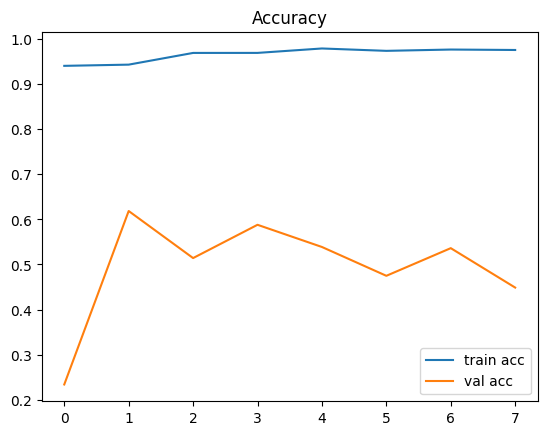

In [14]:
EPOCHS = 30

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5)
]

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

plt.figure()
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.legend()
plt.title("Accuracy")
plt.show()


## 9) Evaluation
- Window-level metrics
- Device-level metrics (mean-prob aggregation)


Window-level classification report:
                       precision    recall  f1-score   support

 continuous_streaming     0.6278    0.9487    0.7556       800
interactive_actuators     0.8127    0.7700    0.7908       400
   low_rate_telemetry     0.0000    0.0000    0.0000       408
  smart_media_clients     0.1226    0.1234    0.1230       462

             accuracy                         0.5430      2070
            macro avg     0.3908    0.4605    0.4173      2070
         weighted avg     0.4270    0.5430    0.4723      2070



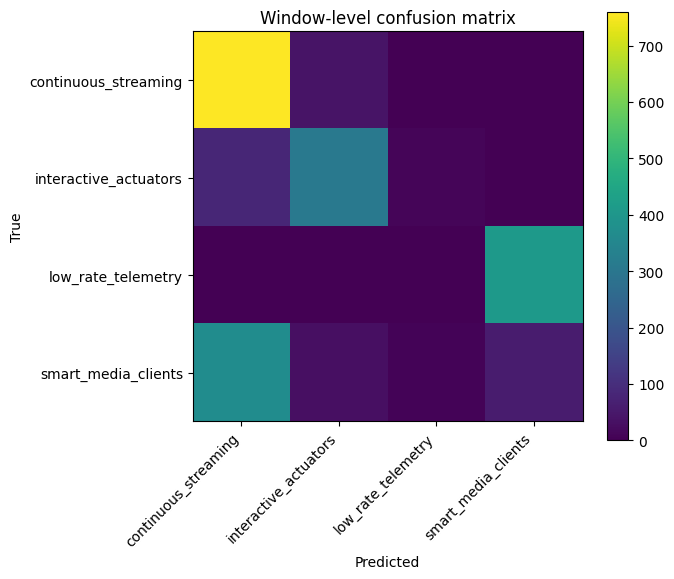


Per-device predictions:
- NestDropCam_308cfb2fe4b2            true=continuous_streaming   pred=continuous_streaming   windows=400
- PixStarPhotoFrame_e076d033bb85      true=smart_media_clients    pred=continuous_streaming   windows=400
- PhilipsHue_0017882b9a25             true=interactive_actuators  pred=interactive_actuators  windows=400
- BlipCareBPMeter_746a89002e25        true=low_rate_telemetry     pred=smart_media_clients    windows=8
- HelloBarbie_28c2ddffa52d            true=smart_media_clients    pred=smart_media_clients    windows=62
- WithingsSmartScale_0024e41b6f96     true=low_rate_telemetry     pred=smart_media_clients    windows=400
- SamsungCamera_00166cab6b88          true=continuous_streaming   pred=continuous_streaming   windows=400

Device-level classification report (mean-prob aggregation):
                       precision    recall  f1-score   support

 continuous_streaming     0.6667    1.0000    0.8000         2
interactive_actuators     1.0000    1.0000    1.

/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zer

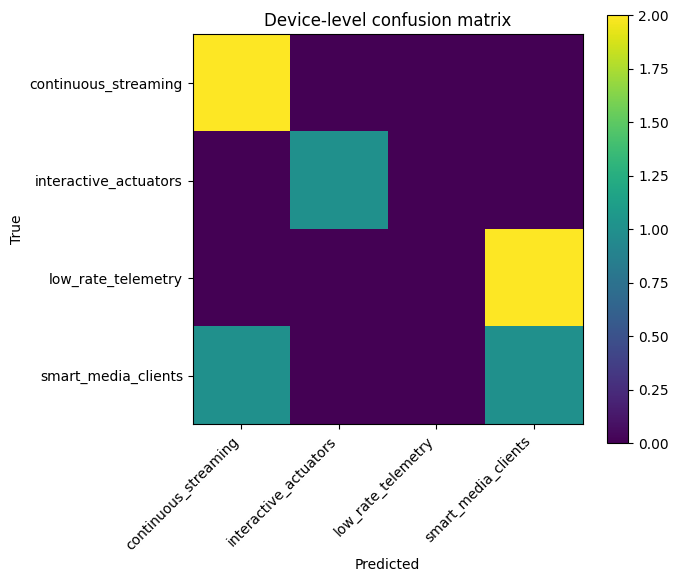

In [15]:
def collect_window_preds(df_sub: pd.DataFrame, model: tf.keras.Model, max_windows_per_device: int = 500):
    all_true = []
    all_pred = []
    per_device = []

    for _, row in df_sub.iterrows():
        dev = row["device_id"]
        y_true = int(row["y"])
        pcap_path = row["pcap_path"]
        device_ip = infer_device_ip(pcap_path, scan_packets=200)

        probs = []
        wcount = 0
        for Xpkt, Xsum, y_ in iter_windows_packet_and_summary(pcap_path, device_ip=device_ip, label=y_true, max_windows=max_windows_per_device):
            p = model.predict([Xpkt[None, ...], Xsum[None, ...]], verbose=0)[0]
            probs.append(p)
            y_hat = int(np.argmax(p))
            all_true.append(y_true)
            all_pred.append(y_hat)
            wcount += 1

        if probs:
            probs_mean = np.mean(np.stack(probs, axis=0), axis=0)
            y_dev = int(np.argmax(probs_mean))
        else:
            probs_mean = np.zeros((n_classes,), dtype=np.float32)
            y_dev = -1

        per_device.append((dev, y_true, probs_mean, y_dev, wcount))

    return np.array(all_true), np.array(all_pred), per_device

win_true, win_pred, dev_preds = collect_window_preds(test_df, model, max_windows_per_device=400)

print("Window-level classification report:")
print(classification_report(win_true, win_pred, target_names=types, digits=4))

cm = confusion_matrix(win_true, win_pred, labels=list(range(n_classes)))
plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Window-level confusion matrix")
plt.colorbar()
plt.xticks(range(n_classes), types, rotation=45, ha="right")
plt.yticks(range(n_classes), types)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

dev_true = []
dev_pred = []
print("\nPer-device predictions:")
for dev, y_true, probs_mean, y_dev, wcount in dev_preds:
    if y_dev >= 0:
        dev_true.append(y_true)
        dev_pred.append(y_dev)
    print(f"- {dev:35s} true={idx_to_type[y_true]:22s} pred={idx_to_type.get(y_dev,'(none)'):22s} windows={wcount}")

dev_true = np.array(dev_true)
dev_pred = np.array(dev_pred)

print("\nDevice-level classification report (mean-prob aggregation):")
print(classification_report(dev_true, dev_pred, target_names=types, digits=4))

cm2 = confusion_matrix(dev_true, dev_pred, labels=list(range(n_classes)))
plt.figure(figsize=(7, 6))
plt.imshow(cm2, interpolation="nearest")
plt.title("Device-level confusion matrix")
plt.colorbar()
plt.xticks(range(n_classes), types, rotation=45, ha="right")
plt.yticks(range(n_classes), types)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


## 10) Notes / knobs
- Overlapping windows: try `STRIDE=30` for better device-level stability
- `dns_like_ratio` and `tls_like_ratio` are included in summaries; if you want to avoid service-based shortcuts, remove them.
- Next (if desired): build `summary + no direction` by setting `direction` to 0 in `iter_windows_packet_and_summary` and recomputing summaries.
